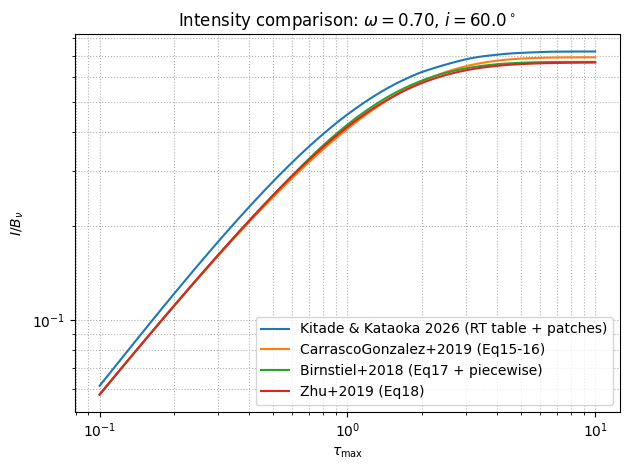

In [8]:
from emergentintensity import (
    emergent_stokes,
    I_carrasco2019_over_Bnu,
    I_birnstiel2018_over_Bnu,
    I_zhu2019_over_Bnu,
)

import numpy as np
import matplotlib.pyplot as plt

omega0 = 0.7
inc0   = 60.0

# tau range (change if needed)
tau = np.logspace(-1, 1, 100)

# Our model (I only)
Ie = np.empty_like(tau, dtype=float)
for i, t in enumerate(tau):
    I, Q = emergent_stokes(float(t), float(omega0), float(inc0))
    Ie[i] = float(I)

# Literature formulas (I only)
Ic = np.array([I_carrasco2019_over_Bnu(float(t), float(omega0), float(inc0)) for t in tau], dtype=float)
Ib = np.array([I_birnstiel2018_over_Bnu(float(t), float(omega0), float(inc0)) for t in tau], dtype=float)
Iz = np.array([I_zhu2019_over_Bnu(float(t), float(omega0), float(inc0)) for t in tau], dtype=float)

plt.figure()
plt.loglog(tau, Ie, label="Kitade & Kataoka 2026 (RT table + patches)")
plt.loglog(tau, Ic, label="CarrascoGonzalez+2019 (Eq15-16)")
plt.loglog(tau, Ib, label="Birnstiel+2018 (Eq17 + piecewise)")
plt.loglog(tau, Iz, label="Zhu+2019 (Eq18)")
plt.xlabel(r"$\tau_{\max}$")
plt.ylabel(r"$I/B_\nu$")
plt.title(
    fr"Intensity comparison: $\omega={omega0:.2f}$, $i={inc0:.1f}^\circ$"
)
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()
plt.show()